In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import wandb
import matplotlib.pyplot as plt
import glob
import os

import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")

from utils.dataset import HyperGraphDataset
from metrics import LAP_loss
from train import get_config, main

# Loading

In [3]:
base_path = "/storage/agrp/dreyet/Hypergraphs/hypergraphflow/configs/"

dataset_names = [
    "convex_hull_normal_3D_30to30",
    "convex_hull_normal_3D_20to100",
    "convex_hull_normal_3D_50to50",
    "convex_hull_spherical_3D_20to100",
    "convex_hull_spherical_3D_30to30",
    "convex_hull_spherical_3D_50to50",
]

dataset_configs = [f"{base_path}{dataset}.yaml" for dataset in dataset_names]

In [4]:
def get_ckpt_path(dataset, expID):
    pattern = f"../{dataset}/{expID}/checkpoints/epoch*/val*.ckpt"
    ckpt_path = glob.glob(pattern)
    if len(ckpt_path) == 0:
        raise ValueError(f"No checkpoints matching pattern: {pattern}")
    elif len(ckpt_path) > 1:
        raise NotImplementedError(f"Multiple checkpoints matching pattern: {pattern}.")
    return os.path.abspath(ckpt_path[0])

In [5]:
### Experiment IDs
refiner_experiments = {
    "convex_hull_spherical_3D_20to100": "lj81co6g",
    "convex_hull_spherical_3D_50to50": "nrw2v8l5",
    "convex_hull_normal_3D_20to100": "1hrog24v",
    "convex_hull_normal_3D_50to50": "j9jp4t8w",
    "convex_hull_spherical_3D_30to30": "bblzv2tj",
    "convex_hull_normal_3D_30to30": "njbf03of",
}

hgflow_experiments = {
    "convex_hull_spherical_3D_20to100": "71r6bgww",
    "convex_hull_spherical_3D_50to50": "eaht6kt2",
    "convex_hull_normal_3D_20to100": "5daqp4h4",
    "convex_hull_normal_3D_50to50": "ywmxchek",
    "convex_hull_spherical_3D_30to30": "405su2cw",
    "convex_hull_normal_3D_30to30": "rpy6nq6q",
}

### Checkpoints
refiner_ckpts = {dataset: get_ckpt_path(dataset, refiner_experiments[dataset]) for dataset in dataset_names}
hgflow_ckpts = {dataset: get_ckpt_path(dataset, hgflow_experiments[dataset]) for dataset in dataset_names}

In [67]:
dataset = "convex_hull_normal_3D_30to30"
config_dataset = f"../configs/{dataset}.yaml"

# config_model = "../configs/refiner.yaml"
config_model = "../configs/hgflow.yaml"
if 'refiner' in config_model:
    ckpt = refiner_ckpts[dataset]
else:
    ckpt = hgflow_ckpts[dataset]

config_train = "../configs/train.yaml"

config = get_config(config_train, config_model, config_dataset)

In [68]:
trainer, model, ds, dls = main(config, mode="test", checkpoint=ckpt)

Seed set to 123456
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Generated dataset convex_hull_normal_3D_30to30 with 24000 examples, 
max nodes: 30, max edges: 40
Splits: train, val, test           with sizes: 20000, 2000, 2000
Loading checkpoint from /storage/agrp/dreyet/Hypergraphs/hypergraphflow/convex_hull_normal_3D_30to30/rpy6nq6q/checkpoints/epoch=epoch=956-step=step=299541-val_loss=loss/val=0.0311.ckpt


# Evaluation

In [69]:
metrics = trainer.validate(model, dataloaders=dls['test'])

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          f1/val           │    0.8377434611320496     │
│         flow/val          │    0.03133073076605797    │
│         loss/val          │    0.03158652409911156    │
│          mae/val          │    1.0815000534057617     │
│       precision/val       │    0.8596323132514954     │
│        recall/val         │    0.8186982274055481     │
└───────────────────────────┴───────────────────────────┘

# Visualization

In [70]:
for batch in dls['test']:
    x, y  = batch
    break

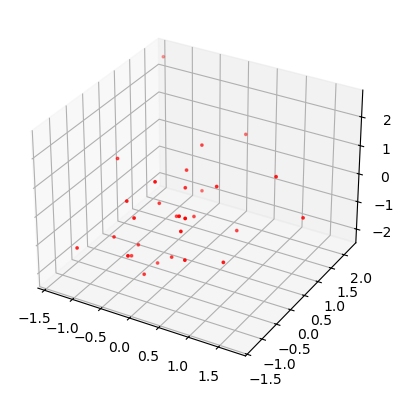

In [71]:
from mpl_toolkits.mplot3d import Axes3D

ex = 3
x = x[ex]
y = y[ex]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], s=3, c='r', marker='o')
plt.show()

In [72]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1)
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

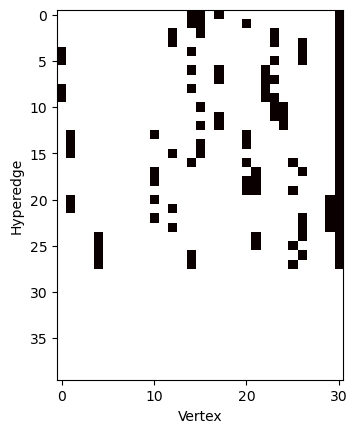

In [73]:
plot_incidence_matrix(y)

In [74]:
def align_incidence_matrix(im_pred, im_true):

    loss, indices = LAP_loss(im_pred, im_true, return_indices=True)
    indices = torch.from_numpy(indices[:,1,...])
    indices = indices.unsqueeze(-1).expand(-1, -1, im_pred.shape[2])

    im_pred_aligned = torch.gather(im_pred, 1, indices)

    return im_pred_aligned, loss, indices

In [75]:
def convert_to_binary(im, threshold=0.5):
    return torch.where(im > threshold, 1, 0)

model.eval()

bs, num_edges, num_nodes = batch[1].shape

if 'refiner' in model.name:
    inputs, target = batch
    e_t, v_t, i_t = model.net.get_initial(inputs)
    seq = model.net(inputs, e_t, v_t, i_t, t_skip=model.config['iters_total']-1, t_bp=1, save_seq=True)[-1]
    aligned_seq = []
    for s in seq:
        aligned_s, _, _ = align_incidence_matrix(s, batch[1])
        aligned_seq.append(aligned_s)

    seq = torch.stack(aligned_seq, dim=0)
    pred = seq[-1]

    loss = LAP_loss(pred, target, n=min(model.config['nray'], inputs.size(0)))

elif model.FM is not None:
    im_0 = model.net.get_init_im(bs, num_edges, num_nodes, device=batch[1].device)
    seq = model.sample(im_0, batch[0], save_seq=True, num_steps=12) #, method='euler')
    im_pred = seq[-1]
    im_pred, loss, indices = model.align_incidence_matrix(im_pred, batch[1])
    seq = torch.stack([model.align_incidence_matrix(s, batch[1])[0] for s in seq])

else:
    raise NotImplementedError()

In [76]:
for idx in range(64):
    im_true = batch[1][idx].cpu().detach().numpy()
    N_ones = im_true.sum()
    N_edges = im_true[:, -1].sum()
    print(f"Hyperedge {idx}: {N_ones} ones, {N_edges} edges")
    

Hyperedge 0: 112.0 ones, 28.0 edges
Hyperedge 1: 88.0 ones, 22.0 edges
Hyperedge 2: 88.0 ones, 22.0 edges
Hyperedge 3: 112.0 ones, 28.0 edges
Hyperedge 4: 88.0 ones, 22.0 edges
Hyperedge 5: 104.0 ones, 26.0 edges
Hyperedge 6: 88.0 ones, 22.0 edges
Hyperedge 7: 104.0 ones, 26.0 edges
Hyperedge 8: 104.0 ones, 26.0 edges
Hyperedge 9: 88.0 ones, 22.0 edges
Hyperedge 10: 80.0 ones, 20.0 edges
Hyperedge 11: 104.0 ones, 26.0 edges
Hyperedge 12: 88.0 ones, 22.0 edges
Hyperedge 13: 104.0 ones, 26.0 edges
Hyperedge 14: 112.0 ones, 28.0 edges
Hyperedge 15: 112.0 ones, 28.0 edges
Hyperedge 16: 80.0 ones, 20.0 edges
Hyperedge 17: 128.0 ones, 32.0 edges
Hyperedge 18: 96.0 ones, 24.0 edges
Hyperedge 19: 72.0 ones, 18.0 edges
Hyperedge 20: 104.0 ones, 26.0 edges
Hyperedge 21: 96.0 ones, 24.0 edges
Hyperedge 22: 96.0 ones, 24.0 edges
Hyperedge 23: 104.0 ones, 26.0 edges
Hyperedge 24: 96.0 ones, 24.0 edges
Hyperedge 25: 112.0 ones, 28.0 edges
Hyperedge 26: 88.0 ones, 22.0 edges
Hyperedge 27: 96.0 ones, 

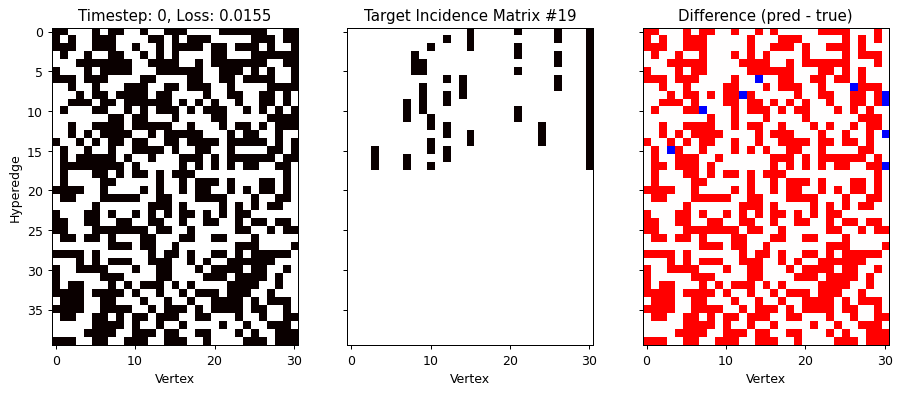

In [81]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True, dpi=90)

idx = 19
to_binary = True

def update(timestep):
    ax[0].clear()
    im_pred = seq[timestep][idx]
    if to_binary:
        im_pred = convert_to_binary(im_pred, 0.5)
    im_pred_np = im_pred.cpu().detach().numpy()
    ax[0].imshow(1 - im_pred_np, cmap='hot', vmin=0, vmax=1, interpolation='nearest')
    ax[0].set_title(f"Timestep: {timestep}, Loss: {loss[idx].mean():.4f}")
    ax[0].set_ylabel("Hyperedge")
    ax[0].set_xlabel("Vertex")

    ax[1].clear()
    im_true = batch[1][idx].cpu().detach().numpy()
    ax[1].imshow(1 - im_true, cmap='hot', vmin=0, vmax=1, interpolation='nearest') 
    ax[1].set_title("Target Incidence Matrix #{}".format(idx))
    ax[1].set_xlabel("Vertex")

    ax[2].clear()
    diff = im_pred_np - im_true
    im = ax[2].imshow(diff, cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
    ax[2].set_title("Difference (pred - true)")
    ax[2].set_xlabel("Vertex")

ani = FuncAnimation(fig, update, frames=seq.shape[0], interval=500)

HTML(ani.to_jshtml())

In [82]:
### save ani as GIF
ani.save(f'{dataset}_animation_{idx}.gif', writer='pillow', fps=2)